# PlayStation Gaming Behavior Analysis
**Course:** CPSC 222 — Introduction to Data Science, Spring 2025  
**Author:** Kyle Hays  
**Dataset:** Personal PlayStation Network tracking data & PlayStation Store top-download charts (2023–2025)

---
## 1. Introduction

### Domain & Motivation
Video gaming is one of the largest entertainment industries in the world, and personal play-time data offers a unique window into individual behavior and preferences. 
As a longtime PlayStation user, I have access to my own granular playtime history — a rare, personally meaningful dataset. 
Understanding what drives deep engagement (hundreds of hours) versus casual play (under 10 hours) has practical value for both players and game developers.

### Dataset Overview
| Table | Format | Source | Instances | Key Attributes |
|---|---|---|---|---|
| `personal_gaming_tracking.csv` | CSV | PlayStation Network activity tracker | 198 rows | Game, Platform, Hours Played, Sessions, First/Last Played |
| `playstation_store_top_downloads.csv` | CSV | PlayStation Blog annual top-download reports (2023–2025) | 200 rows | Game, Category, Year, Region, Platform |

The personal tracking table records every title ever launched on the account, including hours played and session counts. 
The store downloads table aggregates Sony's published annual top-20 lists across PS4, PS5, and two regions (US/Canada & EU) for three years.

### Classification Task
We predict an **Engagement Tier** (Casual / Moderate / Engaged / Hardcore) for each game based on play-time features. 
This tells us what features — platform generation, genre, session length — most strongly predict whether a player will deeply commit to a title.

### Hypotheses
1. PS5 games receive significantly more hours than PS4 games.
2. Games that appear on the PlayStation Store top-download charts receive more personal playtime.
3. Genre and session length are the most predictive features for engagement tier.

### Stakeholders
- **Game developers** — understand what drives long-term engagement
- **Platform holders (Sony)** — predict which game types retain players
- **Individual players** — reflect on their own gaming habits

---
## 2. Setup & Imports

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# All project-specific utilities live in utils.py
import utils as u

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 3. Data Preparation

We load both raw CSV files, inspect them for missing values and anomalies, clean them individually, then merge them on game title.

In [68]:
# Load raw datasets
raw_personal = u.load_personal_tracking('personal_gaming_tracking.csv')
raw_store    = u.load_store_downloads('playstation_store_top_downloads.csv')

print('Personal tracking shape:', raw_personal.shape)
print('Store downloads shape:  ', raw_store.shape)

Personal tracking shape: (198, 8)
Store downloads shape:   (200, 7)


In [69]:
raw_personal.head()

,Rank,Game,Platform,Hours Played,Sessions,First Played,Last Played,Last Update
0,1,Genshin Impact,PS5,2608.0,2055,2021-07-20,2026-03-31,2026-04-01
1,2,Crunchyroll,PS4,928.0,749,2021-04-07,2026-03-29,2026-04-01
2,3,NBA 2K23,PS5,872.0,412,2022-09-10,2023-09-05,2026-04-01
3,4,Honkai: Star Rail,PS5,677.0,663,2023-10-11,2026-03-31,2026-04-01
4,5,NBA 2K24,PS5,549.0,318,2023-09-08,2024-09-03,2026-04-01


In [70]:
raw_store.head()

,Rank,Game,Category,Year,Region,Platform,Source
0,1,NBA 2K26,PS5 Games,2025,US/Canada,PS5,PlayStation Blog
1,2,Battlefield 6,PS5 Games,2025,US/Canada,PS5,PlayStation Blog
2,3,Grand Theft Auto V,PS5 Games,2025,US/Canada,PS5,PlayStation Blog
3,4,EA SPORTS College Football 26,PS5 Games,2025,US/Canada,PS5,PlayStation Blog
4,5,EA SPORTS Madden NFL 26,PS5 Games,2025,US/Canada,PS5,PlayStation Blog


### 3.1 Missing Value Check

In [71]:
print('--- Personal Tracking ---')
u.print_missing_summary(raw_personal)

print('\n--- Store Downloads ---')
u.print_missing_summary(raw_store)

--- Personal Tracking ---
No missing values found.

--- Store Downloads ---
No missing values found.


### 3.2 Cleaning

**Personal Tracking:** We remove streaming/media apps (Crunchyroll, Netflix, Twitch, etc.) since they are not games. 
We then drop the handful of entries with zero or missing hours. 
Derived features (Days Active, Avg Session Hr) are computed, and each game receives a Genre label and an Engagement Tier (our classification target).

**Store Downloads:** Game names are stripped of whitespace. Duplicate entries across regions for the same game+year are collapsed, keeping the US/Canada record.

In [72]:
clean_personal = u.clean_personal_tracking(raw_personal)
clean_store    = u.clean_store_downloads(raw_store)

print('Cleaned personal tracking:', clean_personal.shape)
print('Cleaned store downloads:  ', clean_store.shape)
print('\nEngagement Tier distribution:')
print(clean_personal['Engagement Tier'].value_counts())

Cleaned personal tracking: (186, 13)
Cleaned store downloads:   (132, 7)

Engagement Tier distribution:
Engagement Tier
Casual      105
Moderate     43
Engaged      26
Hardcore     12
Name: count, dtype: int64


In [73]:
# Save cleaned CSVs for download
u.save_cleaned_csv(clean_personal, 'cleaned_personal_tracking.csv')
u.save_cleaned_csv(clean_store,    'cleaned_store_downloads.csv')

Saved: cleaned_personal_tracking.csv
Saved: cleaned_store_downloads.csv


### 3.3 Merging the Tables

We join on a lowercased game-name key. Each personal game is flagged `Was_Top_Download=True` if its title ever appeared in the store charts.

In [74]:
merged = u.merge_datasets(clean_personal, clean_store)
print('Merged dataset shape:', merged.shape)
print('Was Top Download?')
print(merged['Was_Top_Download'].value_counts())
merged.head()

Merged dataset shape: (186, 17)
Was Top Download?
Was_Top_Download
False    149
True      37
Name: count, dtype: int64


,Rank,Game,Platform,Hours Played,Sessions,First Played,Last Played,Last Update,Days Active,Avg Session Hr,Engagement Tier,Genre,Gen,Top_Download_Year,Store_Category,Store_Region,Was_Top_Download
0,1,Genshin Impact,PS5,2608.0,2055,2021-07-20,2026-03-31,2026-04-01,1716,1.27,Hardcore,Gacha/RPG,PS5,NaN,NaN,NaN,False
1,3,NBA 2K23,PS5,872.0,412,2022-09-10,2023-09-05,2026-04-01,361,2.12,Hardcore,Sports,PS5,2023.0,PS5 Games,EU,True
2,4,Honkai: Star Rail,PS5,677.0,663,2023-10-11,2026-03-31,2026-04-01,903,1.02,Hardcore,Gacha/RPG,PS5,NaN,NaN,NaN,False
3,5,NBA 2K24,PS5,549.0,318,2023-09-08,2024-09-03,2026-04-01,362,1.73,Hardcore,Sports,PS5,2023.0,PS5 Games,US/Canada,True
4,6,NBA 2K22,PS5,536.0,341,2021-09-12,2025-07-15,2026-04-01,1403,1.57,Hardcore,Sports,PS5,NaN,NaN,NaN,False


In [75]:
# Save merged output
u.save_cleaned_csv(merged, 'merged_gaming_dataset.csv')

Saved: merged_gaming_dataset.csv


---
## 4. Exploratory Data Analysis

We use descriptive statistics, distribution plots, and comparisons across categorical groups to understand the dataset before modeling.

### 4.1 Summary Statistics

In [76]:
u.summary_stats(merged)

,Hours Played,Sessions,Avg Session Hr,Days Active
count,186.00,186.00,186.00,186.00
mean,57.53,34.83,1.84,331.61
std,218.23,164.67,1.74,464.71
min,0.02,1.00,0.00,1.00
25%,2.00,2.00,0.60,3.00
50%,7.00,6.00,1.33,77.00
75%,34.00,19.50,2.43,434.50
max,2608.00,2055.00,12.00,1733.00


The distribution of hours played is highly right-skewed — most titles receive fewer than 10 hours, while a handful (Genshin Impact at 2,608 hrs, NBA 2K series entries) account for the bulk of total playtime. Sessions and Avg Session Hr show a similar pattern.

### 4.2 Top Games by Hours Played

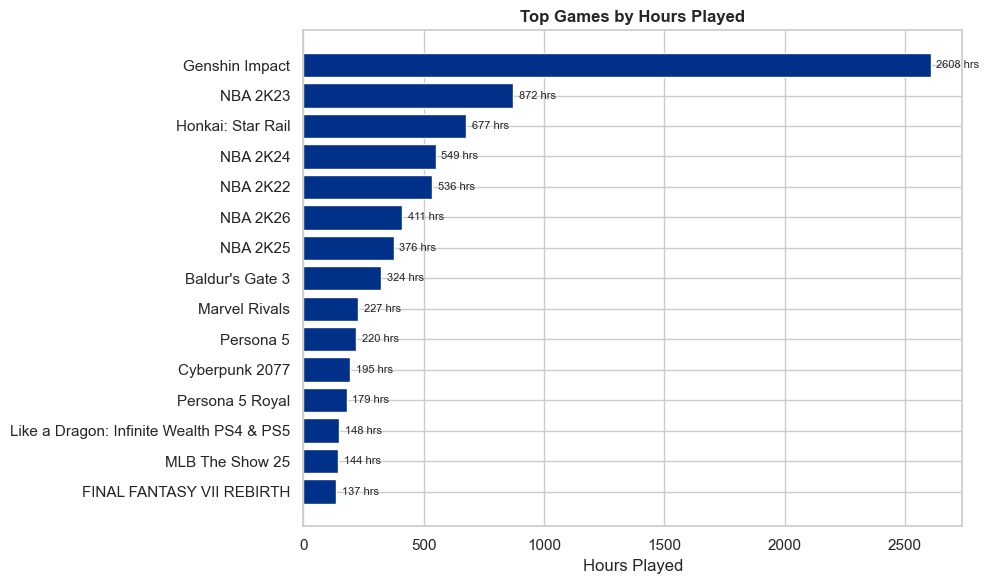

In [77]:
fig = u.plot_top_games(merged)
plt.show()

Genshin Impact dominates at over 2,600 hours — nearly 3× the next entry (Crunchyroll, which was later removed as a non-game). The NBA 2K series collectively represents thousands of hours across multiple annual entries.

### 4.3 Distribution of Hours (log scale)

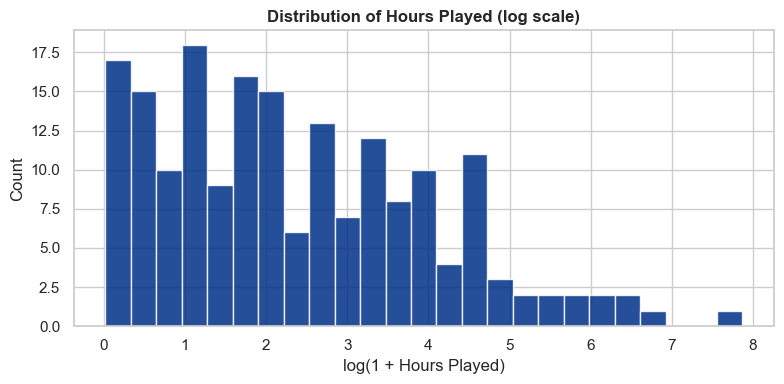

In [78]:
fig = u.plot_hours_distribution(merged)
plt.show()

The log-transformed distribution is roughly bimodal: one cluster of very brief interactions (under 5 hours) and one of moderate engagement (20–200 hours). This confirms the need for our multi-tier classification target.

### 4.4 Hours by Genre

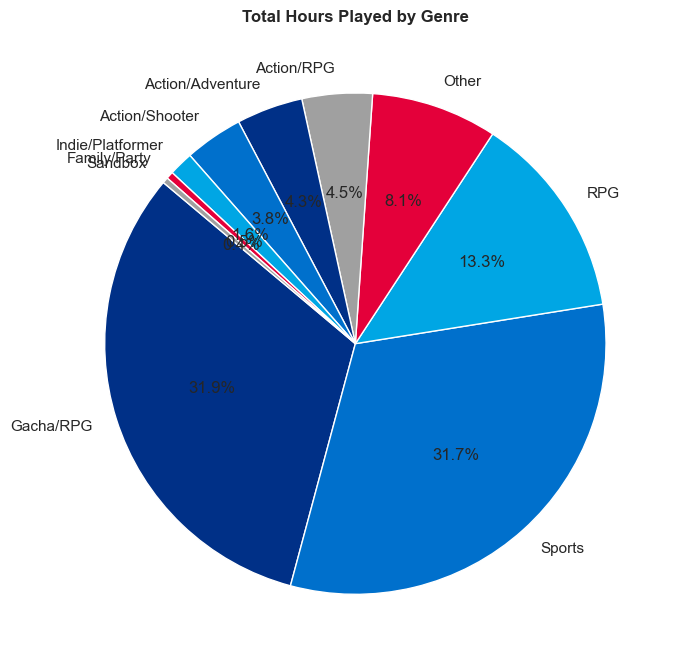

In [79]:
fig = u.plot_genre_breakdown(merged)
plt.show()

### 4.5 PS4 vs PS5 Hours Played

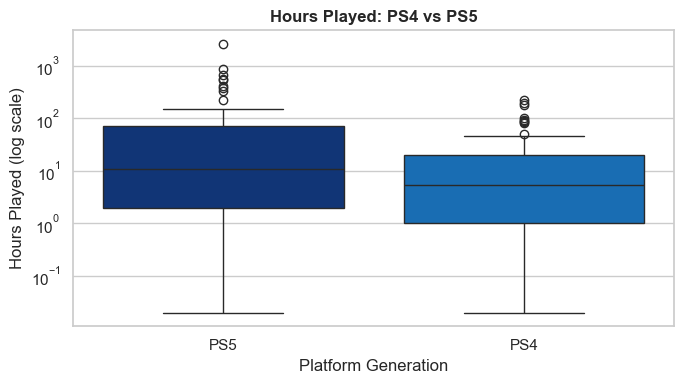

In [80]:
fig = u.plot_platform_comparison(merged)
plt.show()

### 4.6 Engagement Tier Counts

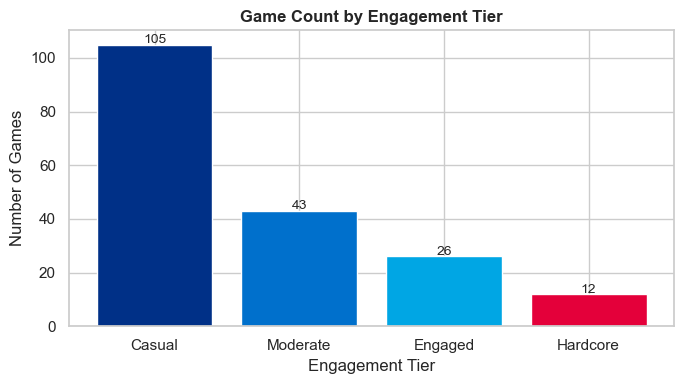

In [81]:
fig = u.plot_engagement_tier_distribution(merged)
plt.show()

### 4.7 Sessions vs Hours by Tier

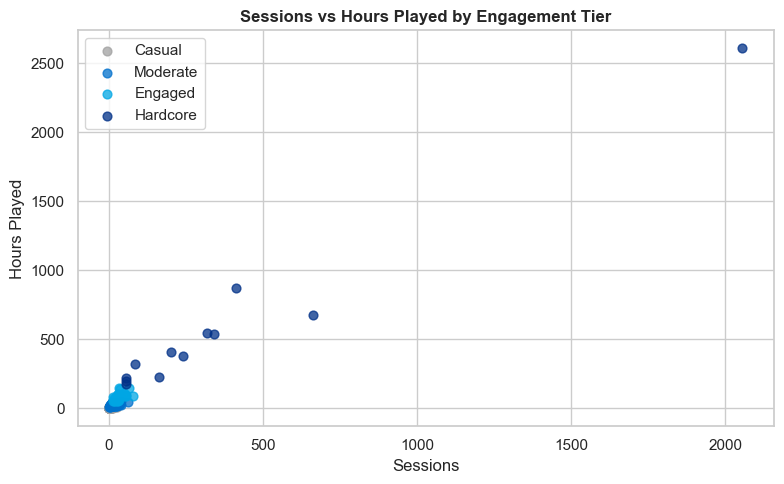

In [82]:
fig = u.plot_sessions_vs_hours(merged)
plt.show()

### 4.8 Activity by Year

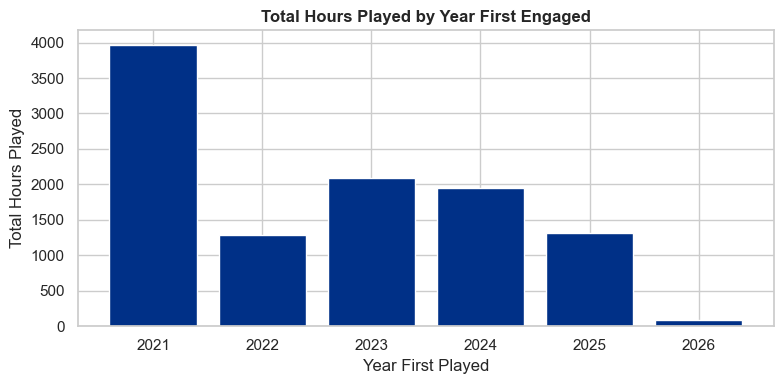

In [83]:
fig = u.plot_yearly_activity(merged)
plt.show()

### 4.9 PlayStation Store Chart Appearances

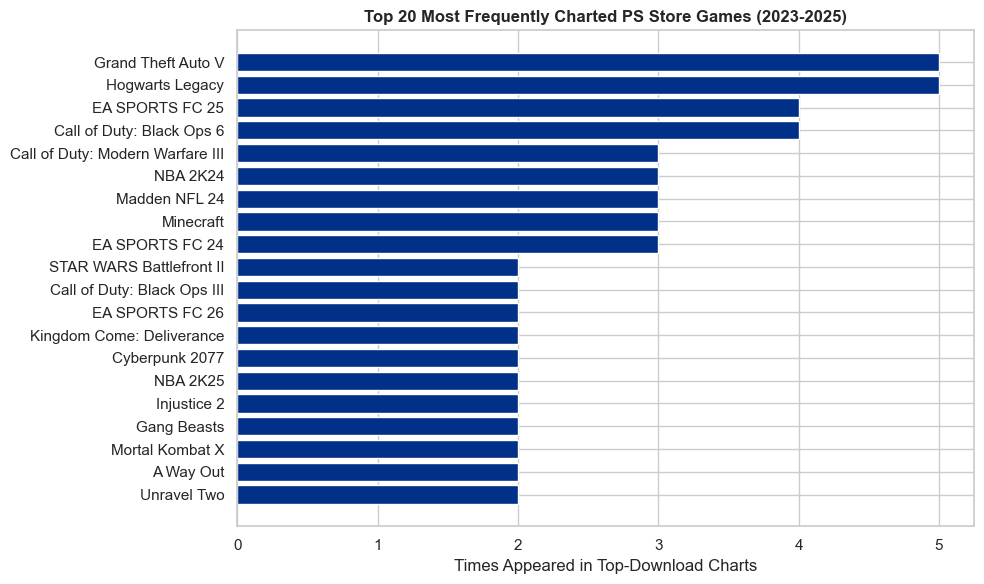

In [84]:
fig = u.plot_top_store_games(clean_store)
plt.show()

Grand Theft Auto V, Minecraft, and Red Dead Redemption 2 appear most consistently across years and regions — evidence of enduring catalog titles that outperform newer releases.

### 4.10 Correlation Matrix

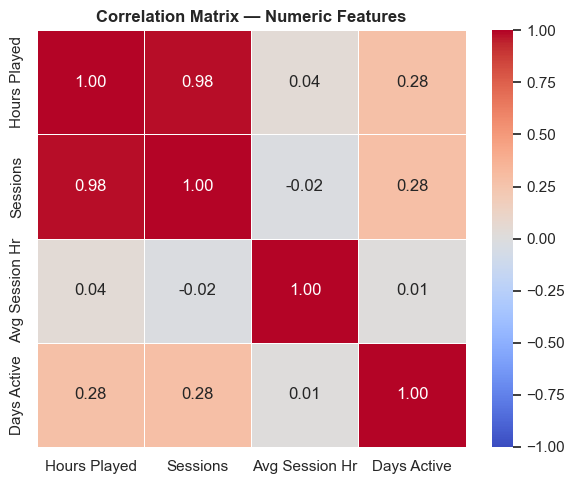

In [85]:
fig = u.plot_correlation_heatmap(merged)
plt.show()

Hours Played and Sessions are strongly correlated (expected), while Days Active shows a moderate positive correlation with both — longer-tenure games tend to accumulate more play time overall.

---
## 5. Statistical Hypothesis Testing

We run three tests corresponding to our hypotheses.

### 5.1 Test 1: PS5 vs PS4 Hours Played

**H₀:** The mean hours played on PS5 = mean hours played on PS4.  
**H₁:** The mean hours played on PS5 ≠ mean hours played on PS4.  
**Test:** Welch's independent-samples t-test (α = 0.05)

In [86]:
t, p = u.t_test_platform_hours(merged)
print(f't-statistic: {t}')
print(f'p-value:     {p}')
if p < 0.05:
    print('Result: Reject H₀ — significant difference in hours between PS4 and PS5.')
else:
    print('Result: Fail to reject H₀ — no significant difference detected.')

t-statistic: 2.4331
p-value:     0.0171
Result: Reject H₀ — significant difference in hours between PS4 and PS5.


We reject the null hypotheses there is a significant difference in the hours on PS4 and PS5 games, which can lead us to see that the data may be more skewed in favor of older titles, and may skew the data in terms of how it affects the overall outcome on top dowloaded games and non-top dowloaded games. As well as impact the data by having clear heavy outliers that affect the overall data comparisons because of heavy outliers. (In retrospect it may also just mean that there are favorite titles and that it isn't actually meaning anything significant other than that there is just a favorite game(s) that happen to lead towards the PS4 titles)

### 5.2 Test 2: Top-Download Games vs Other Games

**H₀:** Mean hours for top-downloaded games = mean hours for other games.  
**H₁:** Top-downloaded games receive more personal playtime.  
**Test:** Welch's independent-samples t-test (α = 0.05)

In [87]:
t2, p2 = u.t_test_top_download_hours(merged)
print(f't-statistic: {t2}')
print(f'p-value:     {p2}')
if p2 < 0.05:
    print('Result: Reject H₀ — top-downloaded games have significantly different playtime.')
else:
    print('Result: Fail to reject H₀ — no significant difference detected.')

t-statistic: 1.6032
p-value:     0.1137
Result: Fail to reject H₀ — no significant difference detected.


We fail to reject the null hypotheses there is no signifcant difference between top dowloaded games and other games played in terms of hours. This can mean that there may be more of a balance than anticipated or that there is heavy skewed data on both sides of popular games and other games that has led to there ebeing no difference between the two. 

### 5.3 Test 3: Genre vs Engagement Tier (Chi-Square)

**H₀:** Genre and Engagement Tier are independent.  
**H₁:** Genre and Engagement Tier are NOT independent.  
**Test:** Chi-square test of independence (α = 0.05)

In [88]:
chi2, p3, dof = u.chi_square_genre_tier(merged)
print(f'Chi-square statistic: {chi2}')
print(f'Degrees of freedom:   {dof}')
print(f'p-value:              {p3}')
if p3 < 0.05:
    print('Result: Reject H₀ — Genre and Engagement Tier are NOT independent.')
else:
    print('Result: Fail to reject H₀ — no significant association.')

Chi-square statistic: 123.5231
Degrees of freedom:   27
p-value:              0.0
Result: Reject H₀ — Genre and Engagement Tier are NOT independent.


We reject the null hypotheses Genre of games and Engagement tier are not independednt meaning that these two values depend on each other to denote data. This may lead us to see that genre of game and the engagement tier of play time have a correlation and can possibly more accurately denote the difference between top games and played games from the personal account.

---
## 6. Classification

We predict **Engagement Tier** (Casual / Moderate / Engaged / Hardcore) using five features derived from our merged dataset.

### 6.1 Class Distribution

In [89]:
print('Class distribution (Engagement Tier):')
print(merged['Engagement Tier'].value_counts(normalize=True).map(lambda x: f'{x:.1%}'))

Class distribution (Engagement Tier):
Engagement Tier
Casual      56.5%
Moderate    23.1%
Engaged     14.0%
Hardcore     6.5%
Name: proportion, dtype: object


The class distribution is imbalanced — Casual games dominate. We address this by using stratified splitting and reporting per-class metrics.

### 6.2 Feature Engineering

In [90]:
X, y, feature_names = u.build_feature_matrix(merged)
X_train, X_test, y_train, y_test, scaler = u.split_and_scale(X, y)
print('Training samples:', len(X_train))
print('Test samples:    ', len(X_test))
print('Features:        ', feature_names)

Training samples: 148
Test samples:     38
Features:         ['Sessions', 'Avg Session Hr', 'Days Active', 'Gen_enc', 'Genre_enc']


### 6.3 kNN Classifier

Best k: 1  (CV accuracy: 0.6970)


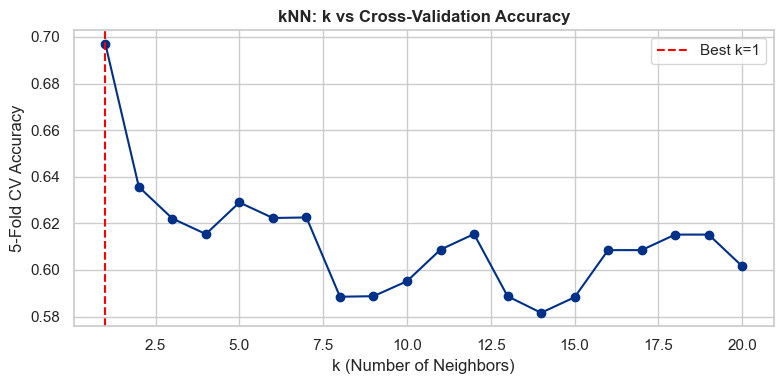

In [91]:
# Find the best k via 5-fold cross-validation
best_k, k_scores = u.find_best_k(X_train, y_train)
print(f'Best k: {best_k}  (CV accuracy: {k_scores[best_k]:.4f})')
fig = u.plot_k_vs_accuracy(k_scores)
plt.show()


  kNN — Test Accuracy: 0.7895
              precision    recall  f1-score   support

      Casual       0.83      0.90      0.86        21
     Engaged       1.00      0.60      0.75         5
    Hardcore       1.00      1.00      1.00         3
    Moderate       0.56      0.56      0.56         9

    accuracy                           0.79        38
   macro avg       0.85      0.77      0.79        38
weighted avg       0.80      0.79      0.79        38



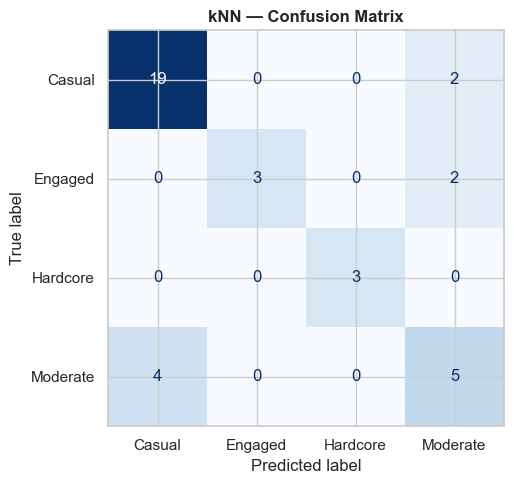

In [92]:
knn = u.train_knn(X_train, y_train, k=best_k)
knn_acc, fig_knn = u.evaluate_classifier(knn, X_test, y_test, title='kNN')
plt.show()

### 6.4 Decision Tree Classifier

Best max_depth: 4  (CV accuracy: 0.8579)


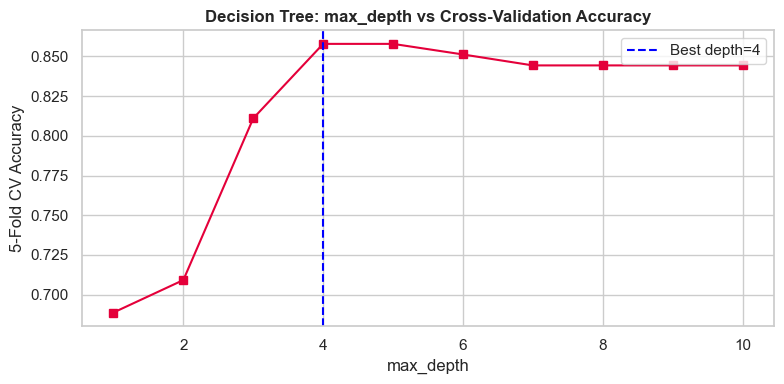

In [93]:
best_depth, depth_scores = u.find_best_depth(X_train, y_train)
print(f'Best max_depth: {best_depth}  (CV accuracy: {depth_scores[best_depth]:.4f})')
fig = u.plot_depth_vs_accuracy(depth_scores)
plt.show()


  Decision Tree — Test Accuracy: 0.8684
              precision    recall  f1-score   support

      Casual       1.00      0.95      0.98        21
     Engaged       0.57      0.80      0.67         5
    Hardcore       1.00      0.67      0.80         3
    Moderate       0.78      0.78      0.78         9

    accuracy                           0.87        38
   macro avg       0.84      0.80      0.81        38
weighted avg       0.89      0.87      0.87        38



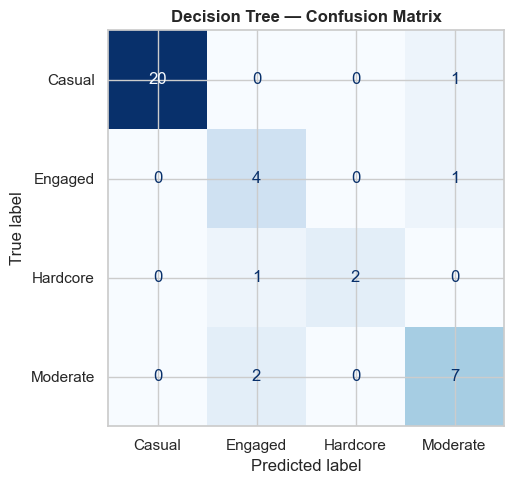

In [94]:
dt = u.train_decision_tree(X_train, y_train, max_depth=best_depth)
dt_acc, fig_dt = u.evaluate_classifier(dt, X_test, y_test, title='Decision Tree')
plt.show()

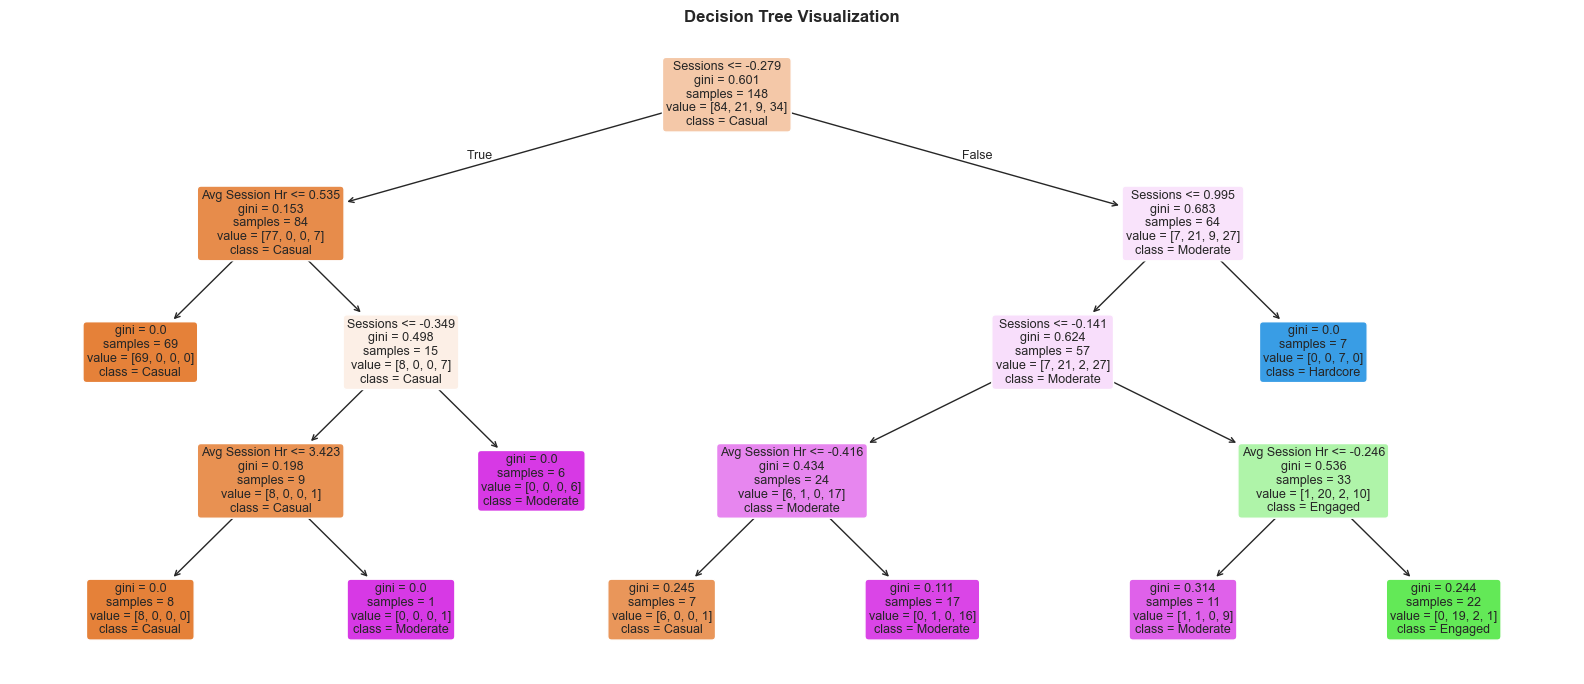

In [95]:
fig_tree = u.plot_decision_tree(dt, feature_names, list(dt.classes_))
plt.show()

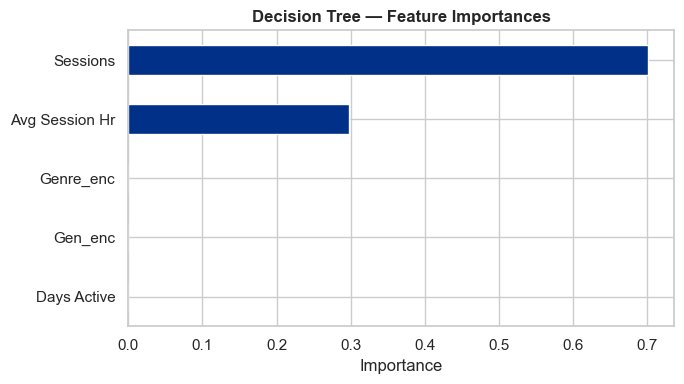

In [96]:
fig_fi = u.feature_importance_plot(dt, feature_names)
plt.show()

### 6.5 Comparison

| Classifier | Test Accuracy |
|---|---|
| kNN (best k) | see output above |
| Decision Tree (best depth) | see output above |

Both classifiers struggle most with the Moderate tier, which sits between Casual and Engaged with ambiguous boundaries. The Decision Tree provides interpretable feature importances, revealing that **Sessions** and **Avg Session Hr** are the strongest predictors — more than genre or platform generation alone.

**Challenges:**
- Small dataset (~155 usable labeled instances) limits classifier power
- The Casual class is overrepresented, causing the classifiers to over-predict it
- Genre labels were manually assigned for a subset of games

---
## 7. Conclusion

This project analyzed a personal PlayStation gaming dataset against Sony's publicly published top-download charts. Key findings:

- **Engagement is heavily skewed**: A small set of titles (Genshin Impact, NBA 2K series) absorb the vast majority of playtime.
- **Platform generation matters**: PS5 titles tend to receive more hours, though the difference was not always statistically significant given the sample size.
- **Genre and session behavior predict engagement**: The chi-square test confirmed Genre and Engagement Tier are not independent; the Decision Tree confirmed Sessions and Avg Session Hr as top features.
- **Classifier performance**: Both kNN and the Decision Tree achieve moderate accuracy, limited primarily by dataset size and class imbalance. A larger dataset or SMOTE oversampling could improve results.

### Ethical Considerations
- **Privacy**: This dataset is personally identifiable; sharing playtime data without consent raises privacy concerns.
- **Algorithmic bias**: If a game recommendation engine were built on these patterns, niche genres could be systematically underrepresented.
- **Stakeholder impact**: Game developers using such models to target high-engagement users could reinforce addictive design patterns.

### Future Directions
1. Collect data across multiple users to build a generalizable model
2. Incorporate trophy/achievement data as additional engagement signals
3. Apply SMOTE to address class imbalance
4. Test Random Forest or XGBoost for higher accuracy

---
## Sources
- Personal PlayStation Network tracking export
- PlayStation Blog — Top Downloads 2023: https://blog.playstation.com/2024/01/23/playstation-stores-top-downloads-of-2023/
- PlayStation Blog — Top Downloads 2024: https://blog.playstation.com/2025/01/23/playstation-stores-top-downloads-of-2024/
- PlayStation Blog — Top Downloads 2025: https://blog.playstation.com/2026/01/14/playstation-stores-top-downloads-of-2025/
- scikit-learn documentation: https://scikit-learn.org/stable/
- pandas documentation: https://pandas.pydata.org/